# Clustering con K-Means e DBSCAN

Questo notebook esplora il dataset **Iris** applicando due algoritmi di clustering non supervisionato: **K-Means** e **DBSCAN**.

L'obiettivo è raggruppare i 150 campioni in cluster significativi senza utilizzare le etichette reali (specie), valutare la qualità del raggruppamento e confrontare i risultati tramite PCA 2D.

### Dataset

| Tipo | Variabili | Descrizione |
|------|-----------|-------------|
| **Features (X)** | `sepal length`, `sepal width`, `petal length`, `petal width` | Misurazioni in cm di sepali e petali |
| **Target (y)** | `setosa`, `versicolor`, `virginica` | Specie di iris — usato solo per il confronto finale |

### Pipeline di Analisi

1. **Caricamento ed esplorazione** del dataset con statistiche descrittive e pair plot
2. **Preprocessing**: standardizzazione con `StandardScaler`
3. **DBSCAN**: clustering density-based con confronto di diversi valori di $\varepsilon$
4. **K-Means**: selezione del k ottimale tramite Elbow Method e Silhouette Score
5. **Visualizzazione PCA 2D**: confronto cluster predetti vs specie reali

### Import & Configurazione

In [1]:
# IMPORT E CONFIGURAZIONE STILE

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# --- Configurazione stile Matplotlib ---
plt.style.use('seaborn-v0_8-whitegrid')

mpl.rcParams.update({
    # Figura
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    # Font
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    # Assi
    'axes.spines.top': False,
    'axes.spines.right': False,
    # Linee e marker
    'lines.linewidth': 2,
    'lines.markersize': 7,
    # Legenda
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.fontsize': 10
})

COLOR = {
    'blue': '#2196F3',
    'red': '#E91E63',
    'green': '#4CAF50',
    'yellow': '#FF9800',
    'purple': '#9C27B0'
}

# --- Configurazione stile tabelle ---
table_style = [
        {'selector': 'caption', 'props': [
            ('font-size', '13px'), ('font-weight', 'bold'),
            ('text-align', 'left'), ('padding-bottom', '6px')]},
        {'selector': 'th',      'props': [
            ('background-color', '#1565C0'), ('color', 'white'),
            ('font-size', '12px'), ('text-align', 'center'),
            ('padding', '6px 12px')]},
        {'selector': 'td',      'props': [
            ('text-align', 'center'), ('padding', '5px 12px'),
            ('font-size', '12px')]},
    ]

## Caricamento e Descrizione Dataset

In [2]:
# CARICAMENTO DATASET IRIS

print('='*80)
print('DATASET IRIS'.center(80))
print('='*80 + '\n')

# Caricamento dati
data_iris = load_iris()

# Descrizione completa del dataset
print(data_iris.DESCR)
print('-'*80 + '\n')

# Features
print('Features')
print('-'*80)
features = data_iris.data
features_names = data_iris.feature_names

print('\nDimensioni features:\n')
print(features.shape)
print('\nNomi features:\n')
print(features_names)
print('\nCampioni features (prime 5 righe):\n')
print(features[:5])
print('-'*80 + '\n')

# Target
print('Target')
print('-'*80)
target_data = data_iris.target
target_names = data_iris.target_names

print('\nDimensioni target:\n')
print(target_data.shape)
print('\nNomi target:\n')
print(target_names)
print('\nCampioni target (prime 5 righe):\n')
print(target_data[:5])
print('='*80)


                                  DATASET IRIS                                  

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Mi

## Statistiche Descrittive

In [3]:
# STATISTICHE DEL DATASET

# Conversione features e target in DataFrame
df_feat = pd.DataFrame(features, columns=features_names)
df_target = pd.DataFrame(target_data, columns=['label'])

print('='*80)
print('STATISTICHE DEL DATASET'.center(80))
print('='*80 + '\n')

# --- Statistiche descrittive delle features ---
print('Features')
print('-'*80)
print('Statistiche descrittive:\n')
print(df_feat.describe().round(2).T.to_string())
X = df_feat.to_numpy()
print('-'*80 + '\n')

# --- Distribuzione delle classi target ---
print('Target')
print('-'*80)
target_values = df_target['label'].unique()
total_target = df_target['label'].count()
df_target['Label'] = df_target['label'].apply(lambda x: target_names[x].capitalize())

print('Distribuzione delle classi:\n')
for label, name_label in zip(target_values, target_names):
    count_label = df_target[df_target['label'] == label]['label'].count()
    print(f'  - {name_label.capitalize():<10}: {count_label/total_target:.2%}')
    
print('='*80)


                            STATISTICHE DEL DATASET                             

Features
--------------------------------------------------------------------------------
Statistiche descrittive:

                   count  mean   std  min  25%   50%  75%  max
sepal length (cm)  150.0  5.84  0.83  4.3  5.1  5.80  6.4  7.9
sepal width (cm)   150.0  3.06  0.44  2.0  2.8  3.00  3.3  4.4
petal length (cm)  150.0  3.76  1.77  1.0  1.6  4.35  5.1  6.9
petal width (cm)   150.0  1.20  0.76  0.1  0.3  1.30  1.8  2.5
--------------------------------------------------------------------------------

Target
--------------------------------------------------------------------------------
Distribuzione delle classi:

  - Setosa    : 33.33%
  - Versicolor: 33.33%
  - Virginica : 33.33%


### Osservazioni

Il dataset è **perfettamente bilanciato** (33.3% per classe): questo rende la valutazione del clustering più affidabile e non introduce distorsioni legate alla distribuzione delle classi.

Le features `petal length` e `petal width` presentano la varianza più alta e la correlazione con la specie target più elevata (>0.94 secondo la descrizione del dataset). Le misurazioni del sepalo sono meno discriminative.


## Visualizzazione Dataset - Pair Plot

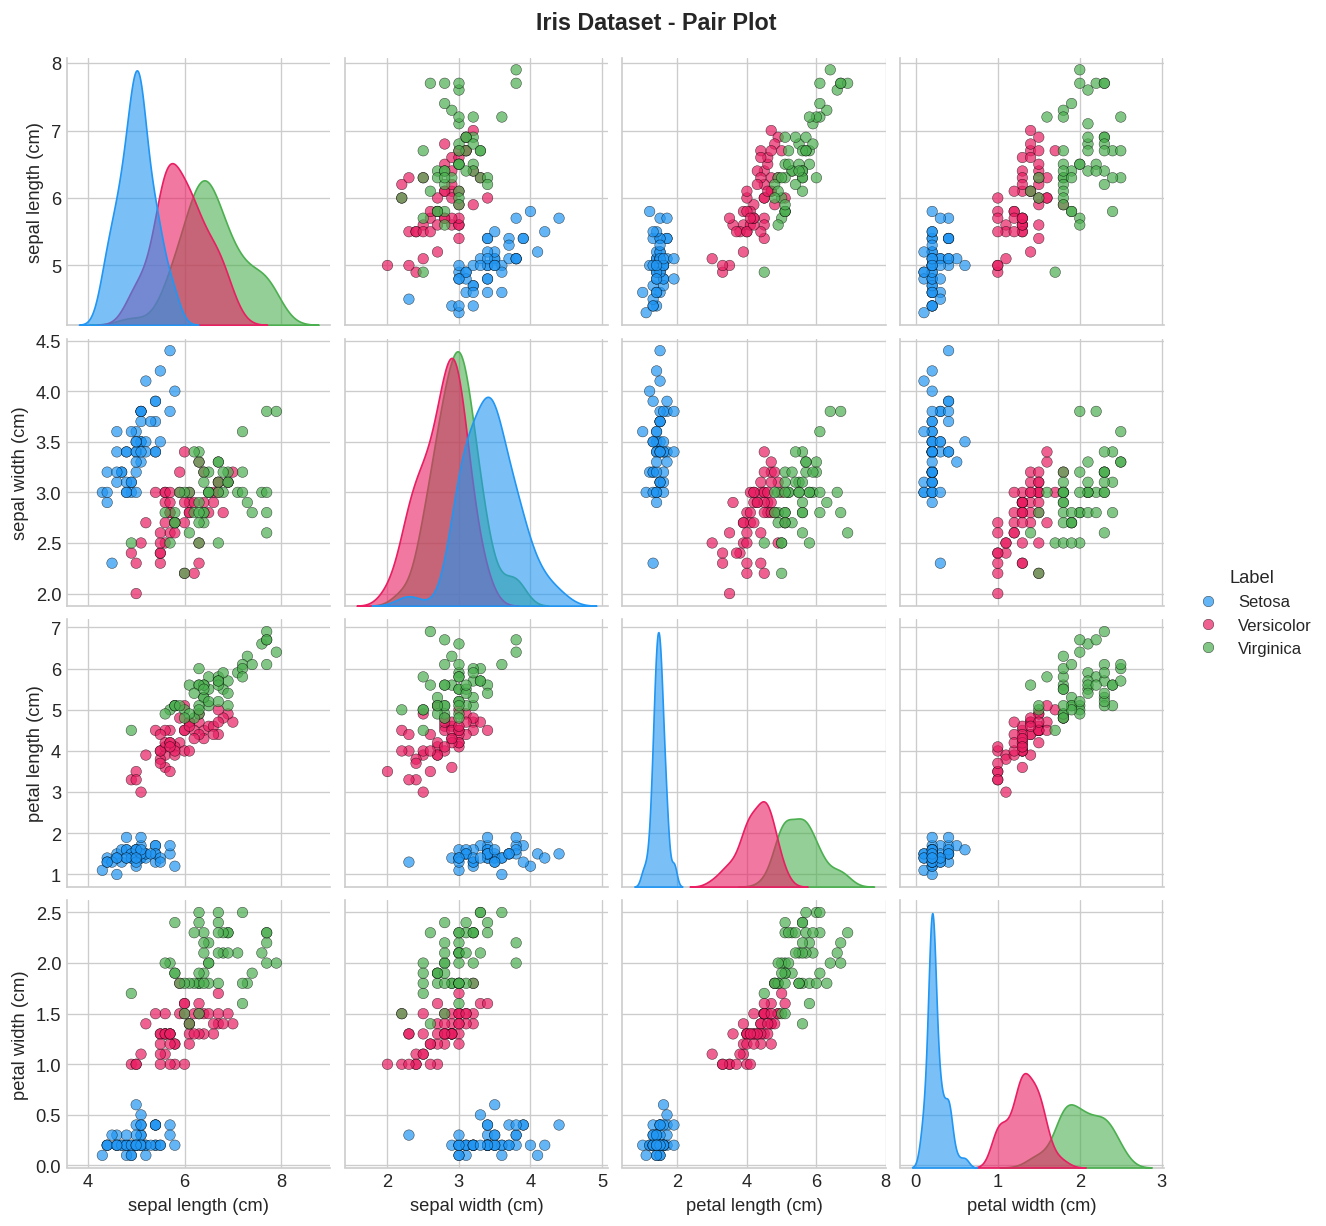

In [4]:
# PAIR PLOT IRIS

# Creazione DataFrame completo (features + target)
df_iris = pd.concat([df_feat, df_target], axis=1)

# Definizione palette
palette = [COLOR['blue'], COLOR['red'], COLOR['green']]

# --- Plot ---
g = sns.pairplot(
    df_iris, hue='Label', vars=features_names, palette=palette,
    plot_kws={'edgecolor': 'k', 'linewidth': 0.3, 'alpha': 0.7, 's': 40},
    diag_kws={'alpha': 0.6}
)
g.figure.suptitle('Iris Dataset - Pair Plot', y=1.02, fontsize=14, fontweight='bold')
plt.show()

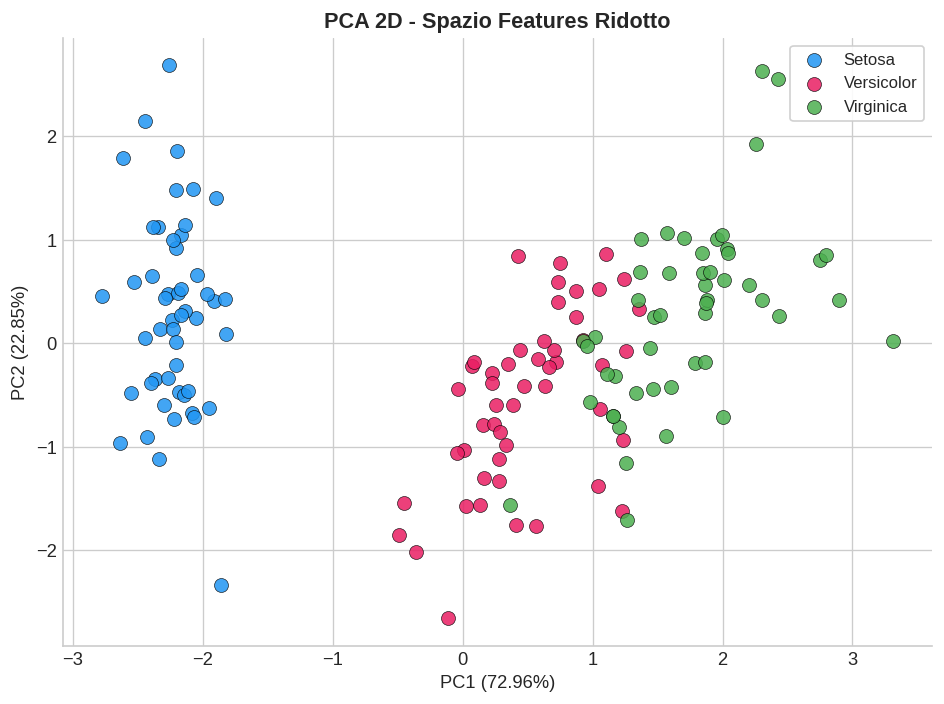

In [5]:
# PCA 2D - FEATURES (EDA)

# --- Standardizzazione Features ---
scaler_eda = StandardScaler()
X_eda      = scaler_eda.fit_transform(X)

# --- Proiezione PCA 2D --- 
pca_eda    = PCA(n_components=2)
X_pca_eda  = pca_eda.fit_transform(X_eda)
var1_eda, var2_eda = pca_eda.explained_variance_ratio_

# Definizione palette
palette = [COLOR['blue'], COLOR['red'], COLOR['green']]

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

# Per ogni specie reale...
for i, name in enumerate(target_names):
    mask = target_data == i
    
    # Scatter specie selezionata
    ax.scatter(
        X_pca_eda[mask, 0], X_pca_eda[mask, 1],
        color=palette[i], 
        label=name.capitalize(),
        edgecolors='k', linewidths=0.4, s=70, alpha=0.85
    )

ax.set_title('PCA 2D - Spazio Features Ridotto')
ax.set_xlabel(f'PC1 ({var1_eda:.2%})')
ax.set_ylabel(f'PC2 ({var2_eda:.2%})')
ax.legend()

plt.tight_layout()
plt.show()

### Osservazioni

Il pair plot evidenzia che la specie **Setosa** è linearmente separabile dalle altre due in quasi tutte le combinazioni di features, in particolare tramite `petal length` e `petal width`. Le specie **Versicolor** e **Virginica** presentano invece una sovrapposizione parziale.

La proiezione PCA 2D conferma questa struttura: **Setosa** appare come un gruppo compatto e ben distante dalle altre due specie, mentre **Versicolor** e **Virginica** si sovrappongono parzialmente. Le prime due componenti principali spiegano complessivamente oltre il 95% della varianza totale, rendendo questa rappresentazione una sintesi fedele dello spazio originale a 4 dimensioni.

## Preprocessing - Standardizzazione

Sia **K-Means** che **DBSCAN** si basano su distanze euclidee: senza scaling, le features con range maggiore dominerebbero il calcolo delle distanze, distorcendo i cluster risultanti.

Prima di applicare gli algoritmi di clustering è dunque necessario **standardizzare** le features con `StandardScaler` (media = 0, std = 1).


In [6]:
# STANDARDIZZAZIONE DELLE FEATURES

# Conversione Feature & Target in numpy array
X = df_feat.to_numpy()
y = df_target['label'].to_numpy()

print('='*80)
print('STANDARDIZZAZIONE DELLE FEATURES'.center(80))
print('='*80 + '\n')

# --- Standardizzazione Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verifica standardizzazione
print('Verifica Features Standardizzate')
for i, name in enumerate(features_names):
    print('\n' + '-'*80)
    print(f'\nFeature {name.capitalize()}:\n')
    print(f'  - Media    :  {X_scaled[:,i].mean():.2e}')
    print(f'  - Dev. std :  {X_scaled[:,i].std():.2f}')
print('\n' + '='*80)

                        STANDARDIZZAZIONE DELLE FEATURES                        

Verifica Features Standardizzate

--------------------------------------------------------------------------------

Feature Sepal length (cm):

  - Media    :  -1.47e-15
  - Dev. std :  1.00

--------------------------------------------------------------------------------

Feature Sepal width (cm):

  - Media    :  -1.82e-15
  - Dev. std :  1.00

--------------------------------------------------------------------------------

Feature Petal length (cm):

  - Media    :  -1.61e-15
  - Dev. std :  1.00

--------------------------------------------------------------------------------

Feature Petal width (cm):

  - Media    :  -9.47e-16
  - Dev. std :  1.00



## Clustering con DBSCAN

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) raggruppa i punti in base alla densità locale: un punto appartiene a un cluster se ha almeno `min_samples` vicini entro un raggio `eps`. I punti che non soddisfano questa condizione vengono classificati come **outlier** (label = −1).

DBSCAN non richiede di specificare il numero di cluster a priori, ma è sensibile al parametro `eps`. Testiamo tre valori  `[0.35, 0.45, 0.55]` con `min_samples = 5` per analizzare la sensibilità dell'algoritmo.

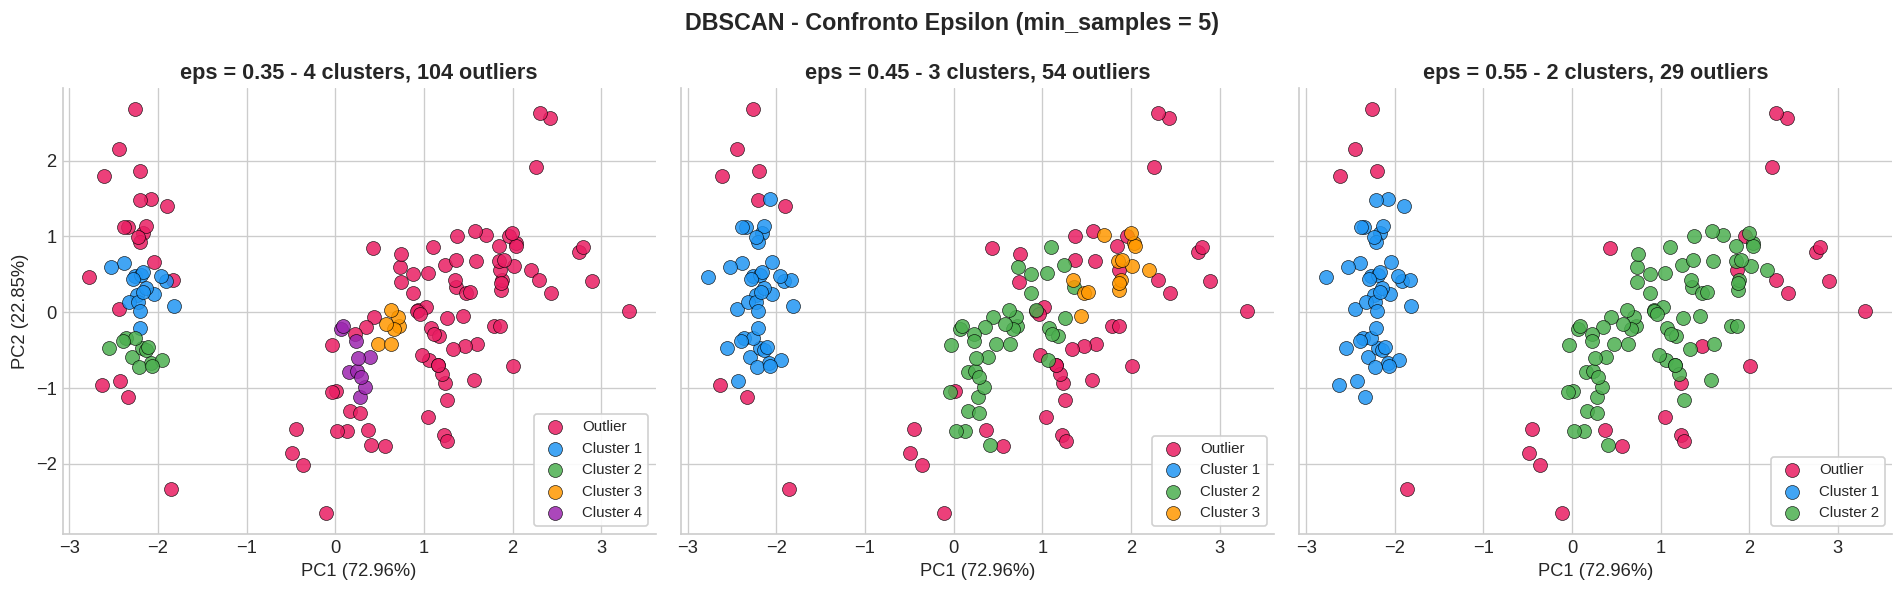

In [7]:
# DBSCAN

# Proiezione PCA 2D per la visualizzazione dei cluster
pca_2d = PCA(n_components=2)
X_pca2d = pca_2d.fit_transform(X_scaled)
var1_db, var2_db = pca_2d.explained_variance_ratio_

# Valori di epsilon 
eps_values    = [0.35, 0.45, 0.55]

# Definizione palette
palette = [COLOR['blue'], COLOR['green'], COLOR['yellow'], COLOR['purple']]
outlier_color = COLOR['red'] 

# Lista risultati
results_rows = []

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle('DBSCAN - Confronto Epsilon (min_samples = 5)', fontsize=14, fontweight='bold')

for ax, eps in zip(axes, eps_values):
    
    # Fit DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=5)
    
    # Predizioni DBSCAN
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = int(labels.max()) + 1
    n_outliers = int((labels == -1).sum())

    # Per ogni classe predetta...
    for lbl in sorted(set(labels)):
        mask  = labels == lbl
        name  = 'Outlier' if lbl == -1 else f'Cluster {lbl + 1}'
        color = outlier_color if lbl == -1 else palette[lbl % len(palette)]
        
        # Scatter classe selezionata
        ax.scatter(
            X_pca2d[mask, 0], X_pca2d[mask, 1],
            color=color, label=name,
            edgecolors='k', linewidths=0.4, s=70, alpha=0.85
        )

        # Append risultati
        results_rows.append({
            'Epsilon': eps, 'Gruppo': name,
            'Campioni': int(mask.sum()),
            '%': f'{mask.sum() / len(labels):.1%}'
        })

    # Titolo subplot
    n_cl_str  = f'{n_clusters} cluster{"s" if n_clusters != 1 else ""}'
    n_out_str = f'{n_outliers} outlier{"s" if n_outliers != 1 else ""}'
    ax.set_title(f'eps = {eps} - {n_cl_str}, {n_out_str}')
    
    # Impostazione xlabel & ylabel
    ax.set_xlabel(f'PC1 ({var1_db:.2%})')
    if ax is axes[0]:
        ax.set_ylabel(f'PC2 ({var2_db:.2%})')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# --- Tabella riepilogativa ---
df_results = pd.DataFrame(results_rows).set_index(['Epsilon', 'Gruppo'])
display(
    df_results.style
    .set_caption('DBSCAN - Distribuzione Cluster')
    .set_table_styles(table_style)
)

### Osservazioni

Al variare di `eps` si osserva il comportamento tipico di DBSCAN:

- **eps basso (0.35)**: più cluster frammentati, maggior numero di outlier - l'algoritmo è "esigente" sulla densità minima
- **eps medio (0.45)**: struttura dei cluster più stabile
- **eps alto (0.55)**: i cluster tendono a fondersi riducendo la granularità della separazione

La visualizzazione nel piano PCA 2D permette di confrontare direttamente la geometria dei cluster al variare del parametro.

## K-Means

**K-Means** suddivide il dataset in `k` cluster minimizzando l'**inertia** - la somma delle distanze euclidee al quadrato tra ciascun punto e il centroide del proprio cluster. Il numero di cluster `k` deve essere specificato a priori: per selezionarlo utilizziamo due tecniche complementari:

- **Elbow Method**: si individua il "gomito" nella curva dell'inertia al variare di k
- **Silhouette Score**: misura quanto ogni campione sia simile al proprio cluster rispetto agli altri (range [−1, 1])

In [8]:
# K-MEANS — CALCOLO INERTIA E SILHOUETTE SCORE PER K DA 1 A 10

k_value = np.arange(1, 11)
inertia_value = []
silhouette_value = []

for k in k_value:
    # Fit K-Means
    kmeans = KMeans(n_clusters=k, random_state=0)
    y_pred = kmeans.fit_predict(X_scaled)
    
    # Inertia
    inertia_value.append(kmeans.inertia_)
    
    # Silhouette Score (non definito per k=1)
    score = silhouette_score(X_scaled, y_pred) if k!=1 else 0
    silhouette_value.append(score)


### Elbow Method

L'**Elbow Method** individua geometricamente il "gomito" della curva dell'**inertia** (somma delle distanze quadratiche al centroide): il punto in cui il guadagno di compattezza diminuisce più bruscamente. Il metodo è implementato calcolando la distanza perpendicolare di ogni punto dalla retta di riferimento che congiunge k=1 e k=10.

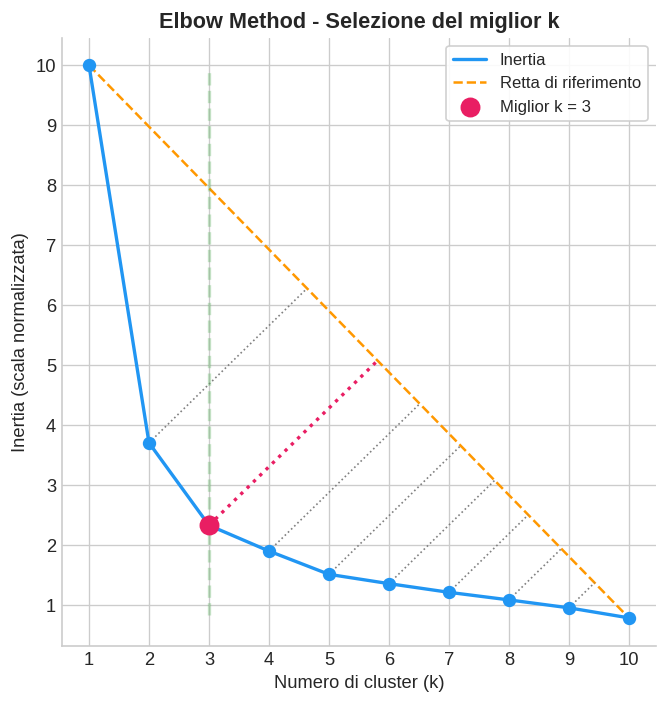

Miglior k: 3


In [9]:
# ELBOW METHOD — SELEZIONE DEL K OTTIMALE

elbow_points = np.array([[k, inertia] for k, inertia in zip(k_value, inertia_value)])
x = elbow_points[:, 0].astype(float)
y = elbow_points[:, 1].astype(float)

# Normalizzazione dell' asse y (inertia) a [0, 10] per un confronto geometricamente corretto
y_norm = 10 * y / y.max()
points_norm = np.column_stack([x, y_norm])

# Retta di riferimento che passa per il primo e l'ultimo punto (spazio normalizzato)
A_n = points_norm[0]
B_n = points_norm[-1]
d_n = B_n - A_n
d_norm_sq = np.dot(d_n, d_n)

# Calcolo del piede perpendicolare e della distanza per ogni punto della curva
distances = []
feet_norm = []
for P_n in points_norm:
    AP = P_n - A_n
    t = np.dot(AP, d_n) / d_norm_sq
    F_n = A_n + t * d_n
    distances.append(np.linalg.norm(P_n - F_n))
    feet_norm.append(F_n)

distances = np.array(distances)
feet_norm = np.array(feet_norm)
feet_x = feet_norm[:, 0]
feet_y = feet_norm[:, 1]

# Best k: punto con la massima distanza perpendicolare dalla retta di riferimento
best_idx = np.argmax(distances)
best_k = int(elbow_points[best_idx, 0])

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 6))

# Elbow Curve
ax.plot(x, y_norm, color=COLOR['blue'], label='Inertia')
ax.scatter(x, y_norm, color=COLOR['blue'], zorder=5)

# Retta di riferimento tra il primo e l'ultimo punto
ax.plot([x[0], x[-1]], [y_norm[0], y_norm[-1]],
        color=COLOR['yellow'], linestyle='--', linewidth=1.5, label='Retta di riferimento')

# Segmenti perpendicolari da ogni punto al rispettivo piede sulla retta
for i in range(len(elbow_points)):
    if i != best_idx:
        ax.plot([x[i], feet_x[i]], [y_norm[i], feet_y[i]],
            color='gray', linewidth=1, linestyle=':')
    
    # Evidenziazione del segmento del miglior k
    else:
        ax.plot([x[i], feet_x[i]], [y_norm[i], feet_y[i]],
            color=COLOR['red'], linewidth=2, linestyle=':')

# Punto del miglior k
ax.scatter(x[best_idx], y_norm[best_idx],
           color=COLOR['red'], zorder=6, s=120, label=f'Miglior k = {best_k}')
ax.axvline(best_k, ymin=0.05, ymax=0.95, color=COLOR['green'], linestyle='--', alpha=0.3)

ax.set_xlabel('Numero di cluster (k)')
ax.set_ylabel('Inertia (scala normalizzata)')
ax.set_title('Elbow Method - Selezione del miglior k')
ax.set_xticks(k_value)
ax.set_yticks(k_value)
ax.set_aspect('equal')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Miglior k: {best_k}')


### Silhouette Score

Il **Silhouette Score** misura quanto ogni campione sia simile al proprio cluster rispetto ai cluster adiacenti (range [−1, 1], valori più alti indicano cluster meglio definiti). Viene calcolato per k da 2 a 10 (non è definito per k=1).

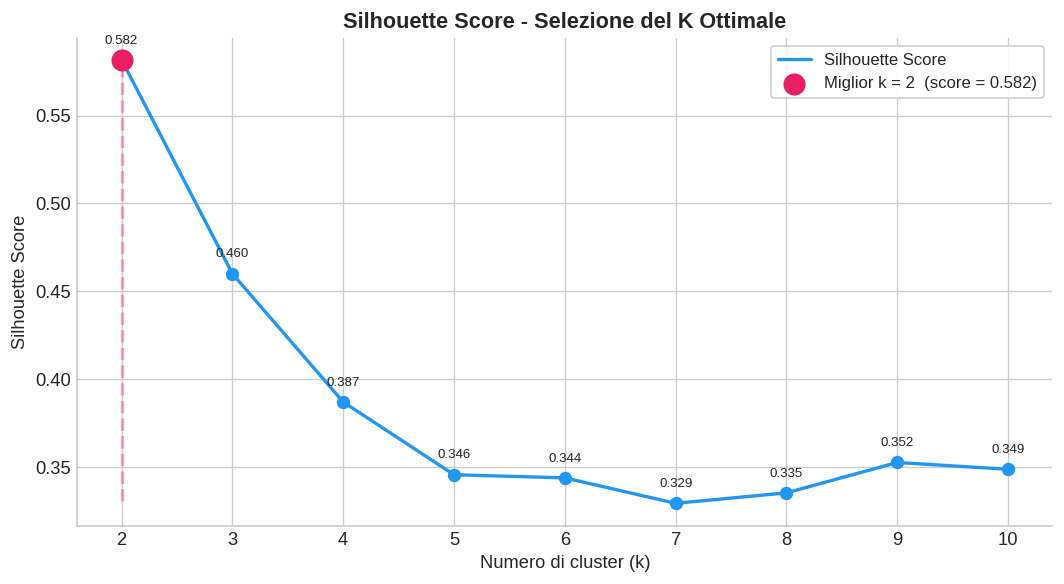

Miglior k - Silhouette Score : 2  (score = 0.5818)
Miglior k - Elbow Method     : 3


In [10]:
# SILHOUETTE SCORE - SELEZIONE DEL K OTTIMALE

# Escludiamo k=1 perché il Silhouette Score non è definito per k=1
x_sil = k_value[1:]
y_sil = np.array(silhouette_value[1:])

# Indice e valore del miglior score
best_sil_idx = int(np.argmax(y_sil))
best_sil_k   = int(x_sil[best_sil_idx])
best_sil_val = float(y_sil[best_sil_idx])

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x_sil, y_sil, color=COLOR['blue'], label='Silhouette Score')
ax.scatter(x_sil, y_sil, color=COLOR['blue'], zorder=5)
ax.scatter(best_sil_k, best_sil_val, color=COLOR['red'], s=150, zorder=6,
           label=f'Miglior k = {best_sil_k}  (score = {best_sil_val:.3f})')
ax.axvline(best_sil_k, ymin=0.05, ymax=0.95, color=COLOR['red'], linestyle='--', alpha=0.35)

# Annotazione del valore dello score su ogni punto della curva
for k_i, s_i in zip(x_sil, y_sil):
    ax.annotate(
        f'{s_i:.3f}', (k_i, s_i),
        textcoords='offset points', xytext=(0, 10),
        fontsize=8, ha='center'
    )

ax.set_title('Silhouette Score - Selezione del K Ottimale')
ax.set_xlabel('Numero di cluster (k)')
ax.set_ylabel('Silhouette Score')
ax.set_xticks(x_sil)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Miglior k - Silhouette Score : {best_sil_k}  (score = {best_sil_val:.4f})')
print(f'Miglior k - Elbow Method     : {best_k}')

### Osservazioni

Il **Silhouette Score** raggiunge il massimo per `k = 2`. Tale risultato è chiaramente errato ma è comunque interessante notare che riflette la distribuzione delle Specie emersa dal Pair Plot e dalla PCA 2D: 
- `Setosa`: compatta e distante dalle altre,
- `Virginica` e `Versicolor`: parzialmente sovrapposte - è plausibile che vengano interpretate come un unico cluster. 

Il valore per `k = 3` rimane elevato e coerente con la struttura reale dei dati. 

In conclusione l'**Elbow Method**, che in questo caso risulta più affidabile, e la conoscenza del dominio convergono verso `k = 3` come scelta ottimale.

### K-Means - Best K

In [11]:
# K-MEANS — ADDESTRAMENTO CON IL K OTTIMALE

# Fit Kmeans con best K
kmeans = KMeans(n_clusters=best_k, random_state=0)
y_pred = kmeans.fit_predict(X_scaled)

# Calcolo del Silhouette Score
sil = silhouette_score(X_scaled, y_pred)

# Tabella di distribuzione dei cluster
df_pred = pd.DataFrame({'cluster': y_pred})
df_pred['Cluster'] = df_pred['cluster'].apply(lambda x: f'Cluster {x + 1}')
dist = df_pred.groupby('Cluster').size().reset_index(name='Campioni')
dist['%'] = (dist['Campioni'] / len(df_pred)).apply(lambda x: f'{x:.1%}')
dist = dist.set_index('Cluster')

print(f'K-Means (k = {best_k}) - Silhouette Score: {sil:.4f}')
display(
    dist.style
    .set_caption(f'Distribuzione Cluster - K-Means (k = {best_k})')
    .set_table_styles(table_style)
)

K-Means (k = 3) - Silhouette Score: 0.4599


,Campioni,%
Cluster,,
Cluster 1,53,35.3%
Cluster 2,50,33.3%
Cluster 3,47,31.3%


## Visualizzazione PCA 2D

Per confrontare i cluster predetti da K-Means con le specie reali, proiettiamo i dati nello spazio delle prime due componenti principali (PCA 2D). I **centroidi** dei cluster vengono anch'essi proiettati nello stesso spazio per verificare la corretta convergenza dell'algoritmo.

Varianza spiegata:
  - PC1    : 72.96%
  - PC2    : 22.85%
  - Totale : 95.81%


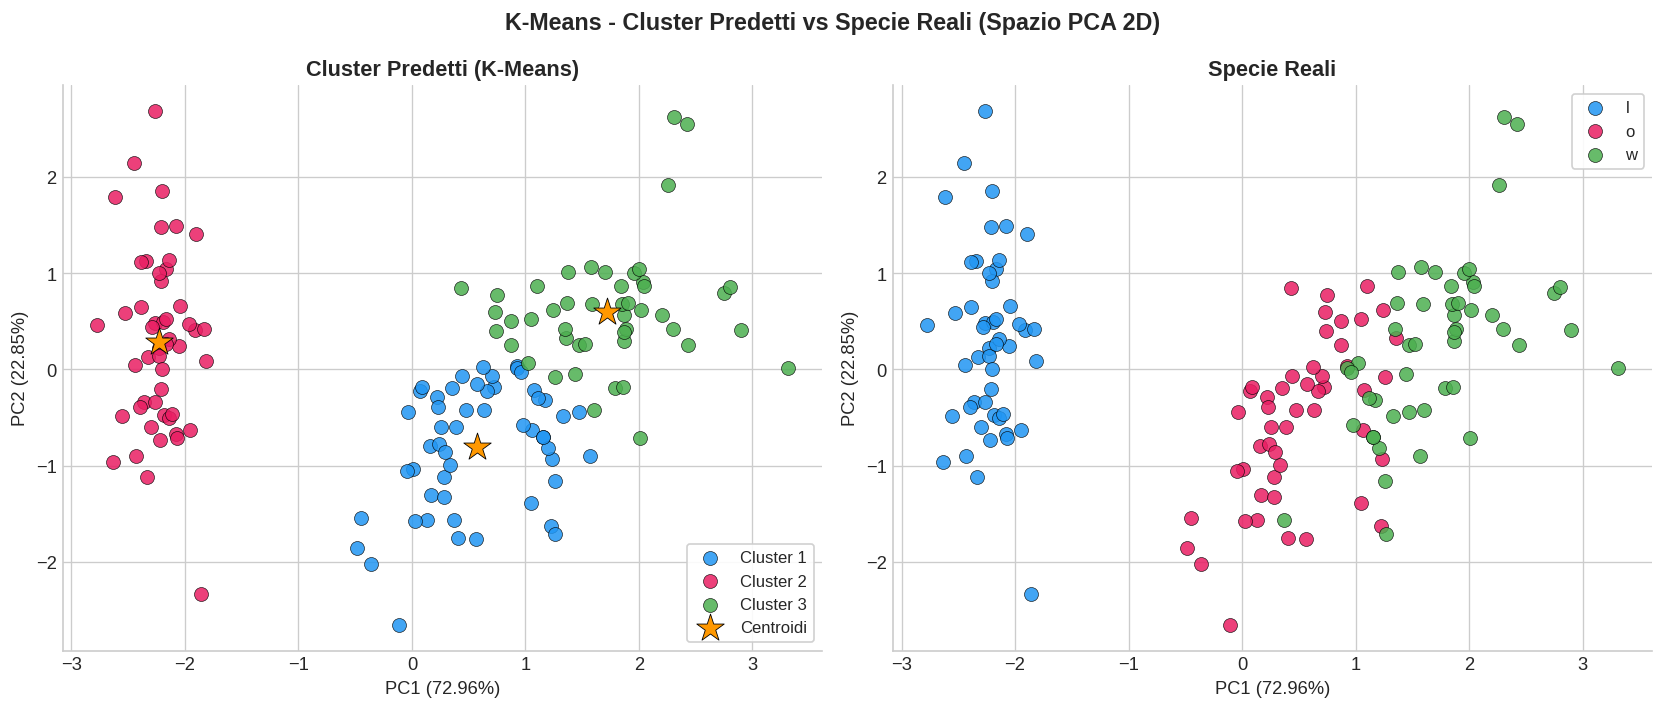

In [16]:
# VISUALIZZAZIONE PCA — Cluster Predetti vs Specie Reali

# Proiezione dei dati standardizzati nelle prime 2 componenti principali
pca_viz = PCA(n_components=2)
X_pca = pca_viz.fit_transform(X_scaled)
var1, var2 = pca_viz.explained_variance_ratio_

print(
    f'Varianza spiegata:' 
    f'\n  - PC1    : {var1:.2%}'
    f'\n  - PC2    : {var2:.2%}'
    f'\n  - Totale : {var1+var2:.2%}'
)

# Proiezione dei centroidi K-Means nello spazio PCA
centroids_pca = pca_viz.transform(kmeans.cluster_centers_)

# Definizione palette
palette = [COLOR['blue'], COLOR['red'], COLOR['green']]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'K-Means - Cluster Predetti vs Specie Reali (Spazio PCA 2D)',
    fontsize=14, fontweight='bold'
)

# Cluster predetti da K-Means ---
ax = axes[0]
for k_lbl in range(best_k):
    mask = y_pred == k_lbl
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=palette[k_lbl % len(palette)],
        label=f'Cluster {k_lbl + 1}',
        edgecolors='k', linewidths=0.4, s=70, alpha=0.85
    )

# Centroidi proiettati nello spazio PCA
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    marker='*', s=300, 
    color=COLOR['yellow'], 
    edgecolors='k', linewidths=0.5,
    zorder=6, label='Centroidi'
    )

ax.set_title('Cluster Predetti (K-Means)')
ax.set_xlabel(f'PC1 ({var1:.2%})')
ax.set_ylabel(f'PC2 ({var2:.2%})')
ax.legend(loc='lower right')

# Specie reali
ax = axes[1]
for i, name in enumerate(target_names):
    mask = target_data == i
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        color=palette[i % len(palette)],
        label=name.capitalize(),
        edgecolors='k', linewidths=0.4, s=70, alpha=0.85
    )
ax.set_title('Specie Reali')
ax.set_xlabel(f'PC1 ({var1:.2%})')
ax.set_ylabel(f'PC2 ({var2:.2%})')
ax.legend('lower right')

plt.tight_layout()
plt.show()

### Osservazioni

La visualizzazione PCA 2D conferma che K-Means riesce a separare correttamente la specie **Setosa** (linearmente separabile dalle altre), mentre confonde parzialmente **Versicolor** e **Virginica** nella zona di sovrapposizione - esattamente come suggeriva il pair plot iniziale.

Le prime due componenti principali spiegano complessivamente oltre il **95% della varianza totale**, rendendo la proiezione 2D una rappresentazione fedele della struttura originale a 4 dimensioni. I **centroidi** (stelle dorate) si posizionano al centro geometrico di ciascun cluster, confermando la corretta convergenza dell'algoritmo.